# FS→DSA Final Analysis — Germany

This notebook guides through an analysis of Germany's MTP and the implications of policy-dependent potential output within the DSA. It can be run top-to-bottom without prior knowledge of the codebase. 

What the notebook will do:
- Load the FS and DSA models. For this excercise, only the supply block of the FS model is relevant: with no structural changes in taxation, the FS supply block is basically equivalent to the key trend equations in the PREM model.
- Enter MTP-informed baseline paths (SPB, potential growth & inflation)
    - Reasoning: We are asusming that the policies named in the MTP are consistent with the specified potential output and inflation paths. I.e.: The specified policy mix will lead to the specified macroeconomic conditions.
    - As GDP is endogenously calculated in the DSA based on PO and output gap, we do not use the (already endogenous) GDP path from the MTP as the baseline.
- Evaluate whether the SPB path from the MTP is still the binding SPB path given newly available data.
- Find the actual binding SPB path to form our baseline.
- Calibrate FS baseline to DSA.
- Run a policy scenario in FS and port it back to DSA.
- Compute the binding SPB path under different potential output assumptuons and compare baseline and scenario SPB target (fiscal space assessment)


## 1) Setup and imports

In [39]:
import sys, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

# Add the model directories to Python path
sys.path.append('model/fs')
sys.path.append('model/dsa/code/classes')

# Direct imports (no package structure)
from data_functions import load_and_process_data
from model_equations import build_model
from scenario_functions import initialize_model, run_scenario_analysis
from integration import apply_mtp_anchors_to_dsa, apply_fs_potential_to_dsa, run_dsa_with_potential_and_spb
from StochasticDsaModelClass import StochasticDsaModel as DSA

# Analysis toggles
START, END = 2025, 2041

## 2) Import data
Load Austria FS data and prepare the DSA model. 

In [40]:
DE = load_and_process_data(data_folder='data', sheet_name='Germany')
FS_model = build_model(include_fiscal=True, include_kg_lag=False)
data_DE = FS_model.insertModelVar(DE)
print('DE data shape:', DE.shape)

# set output gap mechanism in private investment = 0 as we dont assume this effect in PREM yet (all other variables affecting private investment dont change, so no need to adjust them)
data_DE.loc[:, 'LAMBDA_IQ_M_4'] = 0

dsa_de = DSA(country='DEU', start_year=2024, end_year=2041, adjustment_period=7, adjustment_start_year=2025, fiscal_multiplier_type='ec')
dsa_de.project()  # seed baseline arrays
df_de = dsa_de.df(all=True)



DE data shape: (84, 220)


## 3) Specify MTP paths (SPB, potential growth, inflation) and policy measures
The dictionaries below can be edited to specify different assumptions.
- SPB: level path (% of GDP)
- rg_pot: potential GDP growth (percent)
- pi: GDP deflator inflation (percent); available only up to 2029/2031 — we auto-align later years


In [41]:
years_full = list(range(dsa_de.start_year, dsa_de.end_year + 1))

# --- SPB level path from MTP, constant after ---
mtfp_spb_points = {
    2024: -0.9,2025: -1.3, 2026: -1.8, 2027: -1.2, 2028: -0.3,
    2029: 0.5, 2030: 0.8, 2031: 1.1, 2032: 1.1
}
mtfp_spb = pd.Series(mtfp_spb_points).reindex(years_full).interpolate().ffill().bfill()

# --- Potential GDP growth anchors constant after ---
mtfp_rg_pot_points = {
    2025: 0.9, 2026: 0.9, 2027: 0.9, 2028: 0.9, 2029: 0.9, 2030: 0.9, 2031: 0.9
}
mtfp_rg_pot = pd.Series(mtfp_rg_pot_points).reindex(years_full).interpolate().ffill().bfill()

# --- Inflation ---
mtfp_pi_points = {
    2025: 2.7, 2026: 2.6, 2027: 2.6, 2028: 2.6, 2029: 2.5, 2030: 2.5, 2031: 2.4, 2032: 2.4, 2033: 2.3, 2034: 2.3, 2035: 2.2, 2036: 2.2, 2037: 2.2, 2038: 2.2, 2039: 2.2, 2040: 2.2, 2041: 2.2
}

In [42]:
# Apply your MTP inflation and potential growth assumptions
mtp_anchors = {
    'rg_pot': pd.Series(mtfp_rg_pot),  # Potential growth
    'pi': mtfp_pi_points,              # Inflation path
}

# Convert your SPB level path to steps directly
a0 = dsa_de.adjustment_start  # This is 1 (2025)
a1 = dsa_de.adjustment_end    # This is 7 (2031)
years = np.arange(dsa_de.start_year, dsa_de.end_year + 1)  # [2024, 2025, ..., 2045]

# Get your SPB levels aligned to model years
spb_full = mtfp_spb.reindex(years).to_numpy()

# Calculate steps for adjustment period only
spb_steps = np.zeros(dsa_de.adjustment_period)  # Array of 7 zeros
for t in range(a0, a1 + 1):  # t goes from 1 to 7
    spb_steps[t - a0] = spb_full[t] - spb_full[t - 1]

print(f"SPB steps: {spb_steps}")
print(f"SPB levels: {spb_full[1:8]}")  # Show the levels for 2025-2031

SPB steps: [-0.4 -0.5  0.6  0.9  0.8  0.3  0.3]
SPB levels: [-1.3 -1.8 -1.2 -0.3  0.5  0.8  1.1]


## 4) Initialise baseline

Project the debt ratio with the planned policies, assuming that they will lead to the specified potential output, SPB, and inflation changes/levels specified in the plan.

In [43]:
dsa_de.spb_bca[0] = -0.9
dsa_de.spb[0] = -0.9
apply_mtp_anchors_to_dsa(dsa_de, anchors=mtp_anchors, inplace=True)
dsa_de.growth_driven_preclosure = False
dsa_de.project(spb_steps=spb_steps)
df_de = dsa_de.df(all=True)


In [44]:
dsa_bl_opt = copy.deepcopy(dsa_de)
dsa_bl_opt.find_spb_binding(print_results=True, debt_safeguard=False, deficit_resilience=False, edp=False)
df_bl_opt = dsa_bl_opt.df(all=True)

print(f"SPB: {dsa_de.spb_bca[7]:.2f}% vs Binding: {dsa_bl_opt.binding_spb_target:.2f}%")

        Model Params                    SPB Targets       
============================     =========================
country                  DEU     main_adjustment     0.401
adjustment period          7     lower_spb           0.749
adjustment start        2025     financial_stress    0.437
shock frequency    quarterly     adverse_r_g         0.753
stochastic period  2032-2037     deficit_reduction  -0.404
estimation            normal     stochastic          0.541
bond level data        False     binding             0.753
safeguards                                                
============================     =========================

                      Binding Params                      
spb_steps               0.236, 0.236, 0.236, 0.236, 0.236, 0.236, 0.236
spb_target                                           0.753
criterion                                      adverse_r_g
net_expenditure_growth  3.113, 3.013, 3.013, 3.013, 2.913, 2.913, 2.813

SPB: 1.10% vs Binding: 0.75%

In [45]:
# Extract rg_pot and pi series from dsa_at_4
rg = pd.Series(dsa_bl_opt.rg, index=years, name='rg')
rg_pot = pd.Series(dsa_bl_opt.rg_pot, index=years, name='rg_pot')
pi = pd.Series(dsa_bl_opt.pi, index=years, name='pi')

bl_anchors = {
    'rg': rg,
    'rg_pot': rg_pot,
    'pi': pi
}

In [46]:
baseline_DE = initialize_model(
    data=data_DE, 
    model_class=FS_model, 
    start=START, 
    end=END,
    interest_method='exogenous', 
    baseline_method='DSA_MTP',  # This should use your DSA model
    beta_d_assumption='zero', 
    dsa_model=copy.deepcopy(dsa_bl_opt),  # Use the binding DSA model
    mtp_anchors=bl_anchors,
)


Finding instruments :   0%|          | 0/17

## 5) Scenario analysis
Estimate the impact of the policy measures in the FS model, then port the scenario potential into DSA for comparison.

In [47]:
#interpret: absolute means the value is added to the baseline value in that year, delta means only the change to the previous year is added
#persist: will changes persist after scenario timeframe (e.g., after adjustment period)?
#persist_mode: plateau means no further changes (e.g., if EPS_SR = 0.001, it will be 0 in the following years); 
#              copy_last means the last value copied forward (e.g., if EPS_SR = 0.001, EPS_SR will continue to be 0.001 in the following years)

measures = [
    #Measure 1: Fiscal package, assuming that 2029 level is kept constant
    { 'var': 'S_IG_STAR', 'values': [0.420817949, 0.901696279, 0.881651749, 0.87, 0.893377279], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'copy_last' },
]

In [48]:
# Run first scenario to get actual investment levels
sce_temp = run_scenario_analysis(
    baseline_result=baseline_DE, 
    model_class=FS_model,
    scenario_shocks=measures, 
    scenario_name='temp_investment'
)

# Step 2: Extract actual investment levels and calculate labor response
actual_investment = sce_temp.loc[2025:2041, 'I_G_REAL'].values  # Actual investment levels
baseline_investment = baseline_DE.loc[2025:2041, 'I_G_REAL'].values  # Baseline investment

# Calculate additional investment (in millions)
additional_investment_millions = (actual_investment - baseline_investment) / 1e6  # Convert to millions

# Calculate labor force response (5 workers per million additional investment)
labour_multiplier = 5
working_population = sce_temp.loc[2025:2041, 'WP'].values
lp_changes = additional_investment_millions * labour_multiplier / working_population * 100

print("Additional investment (millions):", additional_investment_millions)
print("LP_TREND changes (percentage points):", lp_changes)

# Calculate annual TFP changes based on K_G difference 5 years ago
if 'K_G' in sce_temp.columns and 'K_G' in baseline_DE.columns:
    scenario_capital = sce_temp.loc[2025:2041, 'K_G'].values
    baseline_capital = baseline_DE.loc[2025:2041, 'K_G'].values
    years = sce_temp.loc[2025:2041].index.tolist()
    print("K_G (Scenario):", scenario_capital)
    print("K_G (Baseline):", baseline_capital)
    pct_diff_capital = (scenario_capital - baseline_capital) / baseline_capital * 100
    print("Percentage difference in public capital stock (K_G) between scenario and baseline (%):", pct_diff_capital)
    
    # Calculate annual TFP changes: for year t, TFP change = 0.05 * pct_diff_capital[t-5] (in percent)
    # Store as decimal points (e.g., 0.05 percent = 0.0005)
    tfp_changes_decimal = [0.0] * len(pct_diff_capital)
    for i in range(5, len(pct_diff_capital)):
        tfp_changes_decimal[i] = pct_diff_capital[i-5] * 0.05 / 100  # 0.047% per 1% after 5 years

    print("Annual TFP changes based on K_G difference 5 years ago (decimal):", tfp_changes_decimal)
else:
    print("K_G not found in one of the dataframes. Cannot compute public capital stock difference.")

,Period 1,Period 2,Period 3,Period 4,Period 5,Period 6,Period 7,Period 8,Period 9,Period 10,Period 11,Period 12,Period 13,Period 14,Period 15,Period 16,Period 17
S_IG_STAR,0.420818,0.901696,0.881652,0.87,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

Additional investment (millions): [15350.37250926 33584.5531322  33609.83020288 33865.76906046
 35433.21623012 36073.82790094 36693.79905023 37268.49687753
 37836.83120364 38398.08787889 38947.53267164 39489.83836819
 40025.89804861 40556.48458845 41082.19350594 41602.81679346
 42119.05013327]
LP_TREND changes (percentage points): [0.12093862 0.26480707 0.26537117 0.26783009 0.28062815 0.28608701
 0.29139692 0.29633133 0.30130431 0.30630378 0.31153622 0.31675557
 0.32205549 0.32769441 0.33361503 0.33948401 0.34531171]
K_G (Scenario): [1.38861820e+12 1.45255781e+12 1.51389844e+12 1.57303375e+12
 1.63141515e+12 1.68817324e+12 1.74339132e+12 1.79710107e+12
 1.84938684e+12 1.90032765e+12 1.95002775e+12 1.99855817e+12
 2.04598699e+12 2.09237935e+12 2.13779748e+12 2.18230000e+12
 2.22594310e+12]
K_G (Baseline): [1.37326783e+12 1.40447465e+12 1.43487349e+12 1.46452798e+12
 1.49349693e+12 1.52183401e+12 1.54958814e+12 1.57678315e+12
 1.60345711e+12 1.62964600e+12 1.65541817e+12 1.68080608e+12


In [49]:
# Step 3: Run final scenario with both shocks
final_measures = [
    #Measure 1: Fiscal package, assuming that 2029 level is kept constant
    { 'var': 'S_IG_STAR', 'values': [0.420817949, 0.901696279, 0.881651749, 0.87, 0.893377279], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'copy_last' },

    { 'var': 'EPS_LP', 'values': lp_changes, 'interpret': 'delta', 'persist': True, 'persist_mode': 'copy_last' },

    { 'var': 'EPS_SR', 'values': tfp_changes_decimal, 'interpret': 'delta', 'persist': True, 'persist_mode': 'copy_last' },
]

In [50]:
scenario_DE = run_scenario_analysis(
    baseline_result=baseline_DE, 
    model_class=FS_model,
    scenario_shocks=final_measures, 
    scenario_name='DE_policy'
)

,Period 1,Period 2,Period 3,Period 4,Period 5,Period 6,Period 7,Period 8,Period 9,Period 10,Period 11,Period 12,Period 13,Period 14,Period 15,Period 16,Period 17
S_IG_STAR,0.420818,0.901696,0.881652,0.870000,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377,0.893377
EPS_LP,0.120939,0.143868,0.000564,0.002459,0.012798,0.005459,0.005310,0.004934,0.004973,0.004999,0.005232,0.005219,0.005300,0.005639,0.005921,0.005869,0.005828
EPS_SR,0.000000,0.000000,0.000000,0.000000,0.000000,0.000559,0.001153,0.001042,0.000951,0.000913,0.000848,0.000788,0.000733,0.000682,0.000636,0.000593,0.000554


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

In [51]:
# Calculate total growth from 2024 to 2041 for Germany (DE)
start_value = baseline_DE.loc[2024, 'Y_STAR']
end_value = scenario_DE.loc[2041, 'Y_STAR']
total_growth_factor = end_value / start_value

# Calculate the constant annual growth rate from 2025 to 2041 (17 years)
years_span = 2041 - 2024  # 17 years
constant_growth_rate = (total_growth_factor ** (1/years_span)) - 1

# Create smoothed Y_STAR series with constant growth
scenario_DE['Y_STAR_smooth'] = scenario_DE['Y_STAR'].copy()
scenario_DE.loc[2024, 'Y_STAR_smooth'] = start_value

# Apply constant growth from 2025 onwards
for year in range(2025, 2042):
    scenario_DE.loc[year, 'Y_STAR_smooth'] = start_value * ((1 + constant_growth_rate) ** (year - 2024))

# Calculate the smoothed growth rates
scenario_DE['Y_STAR_growth_smooth'] = scenario_DE['Y_STAR_smooth'].pct_change() * 100

print(f"Total growth factor: {total_growth_factor:.4f}")
print(f"Constant annual growth rate: {constant_growth_rate*100:.2f}%")
print(f"Growth from 2024 to 2041: {(total_growth_factor-1)*100:.2f}%")

Total growth factor: 1.2127
Constant annual growth rate: 1.14%
Growth from 2024 to 2041: 21.27%


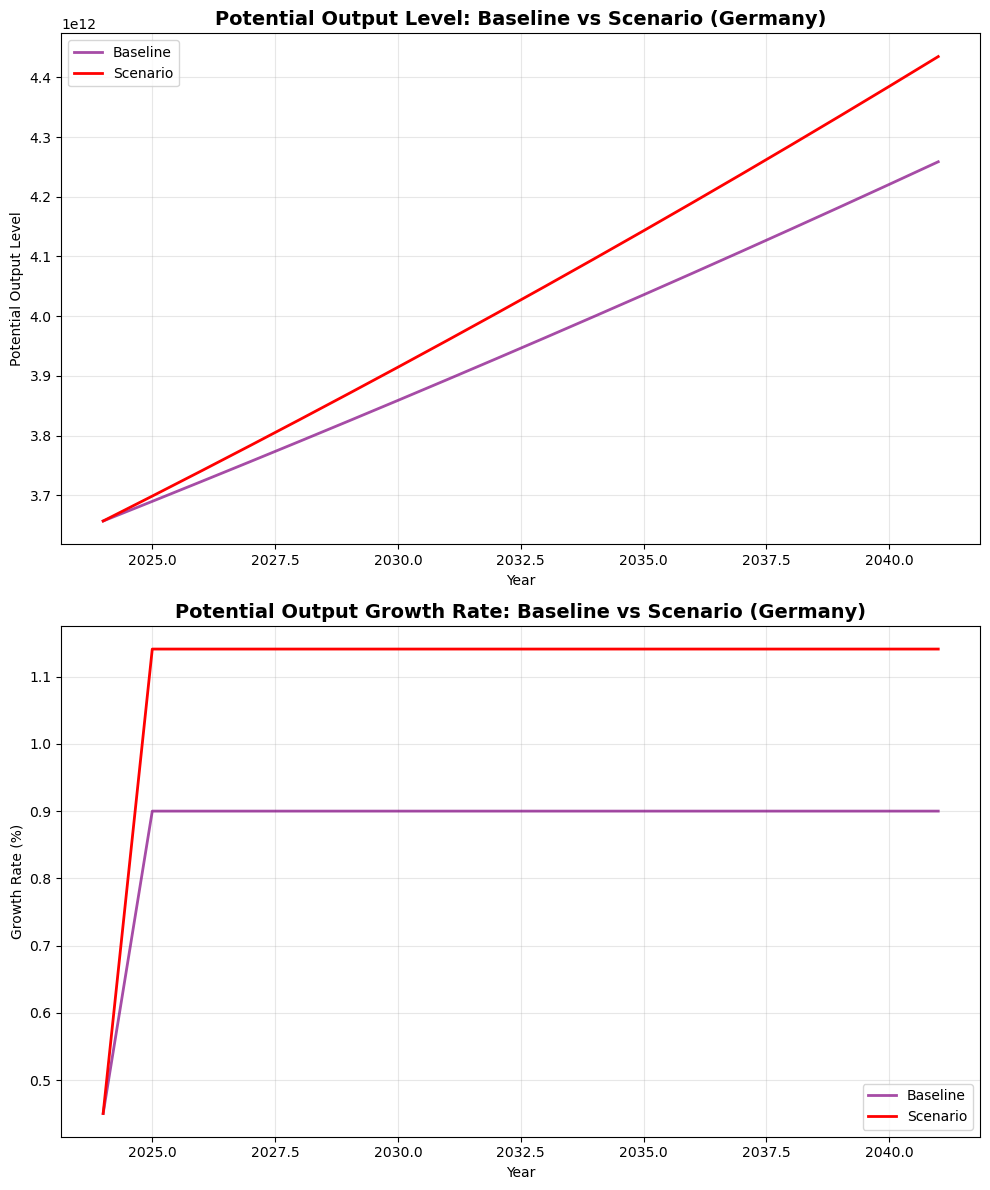

In [52]:
# Compare only baseline vs scenario (smoothed) for Germany
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Define years for x-axis (2024 to 2041)
years_plot = range(2024, 2042)

# First subplot: Baseline vs Scenario (smoothed) Y_STAR levels
ax1.set_title('Potential Output Level: Baseline vs Scenario (Germany)', fontsize=14, fontweight='bold')
ax1.plot(years_plot, baseline_DE.loc[years_plot, 'Y_STAR'], 
         color='purple', linestyle='-', linewidth=2, 
         label='Baseline', alpha=0.7)
ax1.plot(years_plot, scenario_DE.loc[years_plot, 'Y_STAR_smooth'], 
         color='red', linestyle='-', linewidth=2, 
         label='Scenario')
ax1.set_xlabel('Year')
ax1.set_ylabel('Potential Output Level')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Second subplot: Baseline vs Scenario (smoothed) growth rates
ax2.set_title('Potential Output Growth Rate: Baseline vs Scenario (Germany)', fontsize=14, fontweight='bold')
ax2.plot(years_plot, baseline_DE.loc[years_plot, 'G_Y_STAR'], 
         color='purple', linestyle='-', linewidth=2, 
         label='Baseline', alpha=0.7)
ax2.plot(years_plot, scenario_DE.loc[years_plot, 'Y_STAR_growth_smooth'], 
         color='red', linestyle='-', linewidth=2, 
         label='Scenario')
ax2.set_xlabel('Year')
ax2.set_ylabel('Growth Rate (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6) Optimal path & fiscal space
Compare binding SPB paths for baseline and scenario and convert differences into EUR amounts.

In [53]:
# Create DSA model
dsa_scenario = copy.deepcopy(dsa_de)

# Apply only potential output from FS scenarios to DSA models
apply_fs_potential_to_dsa(
    dsa_scenario, 
    fs_df=scenario_DE, 
    use_smoothed_growth=True,
    smooth_start_year=2024,  # Your start year
    smooth_end_year=2041     # Your end year
)



In [54]:
#find optimal/binding SPB path
dsa_sce_opt = copy.deepcopy(dsa_scenario)
dsa_sce_opt.find_spb_binding(
    debt_safeguard=False,
    deficit_resilience=False,
    edp=False,
    print_results=True
)
df_sce_opt = dsa_sce_opt.df(all=True)
    
sce_opt_tgt = float(dsa_sce_opt.binding_spb_target)
sce_opt_steps = dsa_sce_opt.binding_parameter_dict['spb_steps'].copy()

print(f"Baseline Binding: {dsa_bl_opt.spb_bca[7]:.4f}% vs Scenario Binding: {dsa_sce_opt.binding_spb_target:.4f}%")


        Model Params                    SPB Targets       
============================     =========================
country                  DEU     main_adjustment     0.219
adjustment period          7     lower_spb           0.568
adjustment start        2025     financial_stress    0.254
shock frequency    quarterly     adverse_r_g         0.571
stochastic period  2032-2037     deficit_reduction  -0.461
estimation            normal     stochastic          0.401
bond level data        False     binding             0.571
safeguards                                                
============================     =========================

                      Binding Params                      
spb_steps               0.21, 0.21, 0.21, 0.21, 0.21, 0.21, 0.21
spb_target                                           0.571
criterion                                      adverse_r_g
net_expenditure_growth  3.407, 3.307, 3.307, 3.307, 3.207, 3.207, 3.107

Baseline Binding: 0.7533% vs Scenar

In [55]:
# SPB, Debt Ratio, and Potential Output Growth comparison - Baseline vs Scenario for Germany

years_de = range(2025, 2042)  # 2025-2041 for Germany

# Helper function to get EUR values (Germany)
def get_eur_values_de(model, year, var):
    if model.start_year <= year <= model.start_year + len(model.spb_bca) - 1:
        idx = year - model.start_year
        return getattr(model, var)[idx] * model.ngdp[idx] / 100 * 1e9
    return np.nan

# Helper function to get percentage values (Germany)
def get_pct_values_de(model, year, var):
    if hasattr(model, var):
        arr = getattr(model, var)
        if model.start_year <= year <= model.start_year + len(arr) - 1:
            idx = year - model.start_year
            return arr[idx]
    return np.nan

# Create data dictionary for Germany, including debt ratio and potential output growth
results_de = {
    'Jahr': years_de,
    'SPB_Baseline_%': [get_pct_values_de(dsa_bl_opt, y, 'spb_bca') for y in years_de],
    'SPB_Scenario_%': [get_pct_values_de(dsa_sce_opt, y, 'spb_bca') for y in years_de],
    'SPB_Baseline_EUR': [get_eur_values_de(dsa_bl_opt, y, 'spb_bca') for y in years_de],
    'SPB_Scenario_EUR': [get_eur_values_de(dsa_sce_opt, y, 'spb_bca') for y in years_de],
    'Schuldenquote_Baseline_%': [get_pct_values_de(dsa_bl_opt, y, 'd') for y in years_de],
    'Schuldenquote_Scenario_%': [get_pct_values_de(dsa_sce_opt, y, 'd') for y in years_de],
    'Potenzialwachstum_Baseline_%': [get_pct_values_de(dsa_bl_opt, y, 'rg_pot') for y in years_de],
    'Potenzialwachstum_Scenario_%': [get_pct_values_de(dsa_sce_opt, y, 'rg_pot') for y in years_de],
}

# Create DataFrame for Germany
comparison_df_de = pd.DataFrame(results_de)

# Calculate differences for Germany
comparison_df_de['SPB_Diff_%'] = comparison_df_de['SPB_Scenario_%'] - comparison_df_de['SPB_Baseline_%']
comparison_df_de['SPB_Diff_EUR'] = comparison_df_de['SPB_Scenario_EUR'] - comparison_df_de['SPB_Baseline_EUR']
comparison_df_de['Schuldenquote_Diff_%'] = comparison_df_de['Schuldenquote_Scenario_%'] - comparison_df_de['Schuldenquote_Baseline_%']
comparison_df_de['Potenzialwachstum_Diff_%'] = comparison_df_de['Potenzialwachstum_Scenario_%'] - comparison_df_de['Potenzialwachstum_Baseline_%']

print("SPB, Schuldenquote und Potenzialwachstum: Vergleich Baseline vs. Szenario (Deutschland)")
# Format EUR columns to show in billions (no scientific notation)
eur_cols_de = ['SPB_Baseline_EUR', 'SPB_Scenario_EUR', 'SPB_Diff_EUR']
comparison_df_display_de = comparison_df_de.copy()
for col in eur_cols_de:
    comparison_df_display_de[col] = comparison_df_display_de[col].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")

display(comparison_df_display_de.round(2))

SPB, Schuldenquote und Potenzialwachstum: Vergleich Baseline vs. Szenario (Deutschland)


,Jahr,SPB_Baseline_%,SPB_Scenario_%,SPB_Baseline_EUR,SPB_Scenario_EUR,Schuldenquote_Baseline_%,Schuldenquote_Scenario_%,Potenzialwachstum_Baseline_%,Potenzialwachstum_Scenario_%,SPB_Diff_%,SPB_Diff_EUR,Schuldenquote_Diff_%,Potenzialwachstum_Diff_%
0,2025,-0.66,-0.69,"-29,349,096,558","-30,578,275,144",63.83,63.69,0.9,1.14,-0.03,"-1,229,178,586",-0.14,0.24
1,2026,-0.43,-0.48,"-19,606,969,686","-22,105,206,176",64.25,63.99,0.9,1.14,-0.05,"-2,498,236,489",-0.26,0.24
2,2027,-0.19,-0.27,"-9,134,507,084","-12,956,486,328",63.92,63.57,0.9,1.14,-0.08,"-3,821,979,244",-0.36,0.24
3,2028,0.04,-0.06,"2,218,680,938","-2,969,474,761",63.38,62.96,0.9,1.14,-0.10,"-5,188,155,699",-0.42,0.24
4,2029,0.28,0.15,"14,436,818,207","7,849,459,197",62.70,62.24,0.9,1.14,-0.13,"-6,587,359,010",-0.46,0.24
5,2030,0.52,0.36,"27,525,603,605","19,504,453,968",61.83,61.36,0.9,1.14,-0.16,"-8,021,149,637",-0.47,0.24
6,2031,0.75,0.57,"41,471,679,115","31,993,149,757",60.84,60.39,0.9,1.14,-0.18,"-9,478,529,359",-0.45,0.24
7,2032,0.75,0.57,"42,954,989,590","33,210,386,321",59.84,59.43,0.9,1.14,-0.18,"-9,744,603,269",-0.41,0.24
8,2033,0.75,0.57,"44,447,635,208","34,440,090,264",58.95,58.59,0.9,1.14,-0.18,"-10,007,544,944",-0.36,0.24
9,2034,0.75,0.57,"45,991,871,283","35,715,142,923",58.10,57.80,0.9,1.14,-0.18,"-10,276,728,360",-0.30,0.24


In [56]:
# Berechne den durchschnittlichen Anpassungsbedarf im SPB (in %-Punkten BIP) für 2025-2031
# Dies entspricht: Für jedes Jahr (2025-2031) berechne (SPB_Scenario_% - SPB_Baseline_%), dann bilde den Durchschnitt dieser Differenzen.
adj_years = list(range(2025, 2032))
spb_diff_per_year = comparison_df_de.loc[comparison_df_de['Jahr'].isin(adj_years), 'SPB_Scenario_%'] - comparison_df_de.loc[comparison_df_de['Jahr'].isin(adj_years), 'SPB_Baseline_%']
spb_diff_avg = spb_diff_per_year.mean()
print(f"Durchschnittliche SPB-Anpassung 2025-2031 (Szenario minus Baseline): {spb_diff_avg:.2f} Prozentpunkte BIP")

# Berechne die Differenz im Ziel-SPB (letztes Jahr der Anpassungsperiode)
target_year = adj_years[-1]
spb_target_baseline = comparison_df_de.loc[comparison_df_de['Jahr'] == target_year, 'SPB_Baseline_%'].values[0]
spb_target_scenario = comparison_df_de.loc[comparison_df_de['Jahr'] == target_year, 'SPB_Scenario_%'].values[0]
spb_target_diff = spb_target_scenario - spb_target_baseline
print(f"SPB-Ziel (2031) Differenz (Szenario minus Baseline): {spb_target_diff:.2f} Prozentpunkte BIP")

Durchschnittliche SPB-Anpassung 2025-2031 (Szenario minus Baseline): -0.10 Prozentpunkte BIP
SPB-Ziel (2031) Differenz (Szenario minus Baseline): -0.18 Prozentpunkte BIP


In [ ]:
# Save the comparison dataframe for Germany
#comparison_df_de.to_excel('Germany_Results_v2.xlsx', index=False)
#print("DataFrame saved as 'Germany_Results_v2.xlsx'")

DataFrame saved as 'Germany_Results_v2.xlsx'
